# Phase 04 — XGBoost cho Fraud Detection

**Owner:** Mỷ Cẩm  
Huấn luyện XGBoost trên dữ liệu SMOTE, tinh chỉnh siêu tham số (`RandomizedSearchCV`), đánh giá trên test set và so sánh với Random Forest.

> Logic gốc nằm ở `src/models/xgboost_model.py` và `run_xgboost.py`.


## 0. Imports & Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # notebooks/ -> project root
if sys.platform == "win32" and hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import DATA_PROCESSED_DIR, RANDOM_STATE, set_seeds
set_seeds(RANDOM_STATE)

PROC = os.path.join("..", DATA_PROCESSED_DIR)

def load(name):
    with open(os.path.join(PROC, f"{name}.pkl"), "rb") as f:
        return pickle.load(f)

from src.models.xgboost_model import (
    train_xgboost, predict, evaluate_model, get_feature_importance, save_model,
)

## 1. Load SMOTE Data

In [2]:
X_smote, y_smote = load("X_train_smote"), load("y_train_smote")
X_test, y_test = load("X_test"), load("y_test")
feature_names = list(X_test.columns)
print("SMOTE train:", X_smote.shape, " Test:", X_test.shape)
print("Test fraud ratio:", round(float(y_test.mean()), 5))

SMOTE train: (230145, 14)  Test: (40000, 14)
Test fraud ratio: 0.04108


## 2. Train XGBoost (RandomizedSearchCV)
Đặt `tune=False` để lấy nhanh một baseline; `tune=True` để chạy tuning đầy đủ.

In [3]:
model, info = train_xgboost(X_smote, y_smote, tune=True, n_iter=20, cv=3, scoring="f1")
info

🔍 RandomizedSearchCV: n_iter=20, cv=3, scoring=f1
Fitting 3 folds for each of 20 candidates, totalling 60 fits


✅ Best CV f1: 0.9994
⏱️ Training time: 43.7s
📋 Best params: {'subsample': 0.85, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}


{'best_params': {'subsample': 0.85,
  'n_estimators': 300,
  'min_child_weight': 3,
  'max_depth': 8,
  'learning_rate': 0.2,
  'gamma': 0.1,
  'colsample_bytree': 1.0},
 'best_cv_score': 0.9994,
 'training_time_seconds': 43.73,
 'n_iter': 20,
 'cv': 3,
 'scoring': 'f1',
 'scale_pos_weight': 1.0,
 'tuned': True}

## 3. Feature Importance (XGBoost built-in)

,Feature,Importance
0,errorBalanceOrig,0.499405
1,newbalanceOrig,0.471707
2,errorBalanceDest,0.009765
3,is_drain_account,0.005920
4,amount,0.004937
5,oldbalanceOrg,0.003297
6,amount_to_oldbalance_ratio,0.001673
7,type_TRANSFER,0.001006
8,oldbalanceDest,0.000742
9,step,0.000631


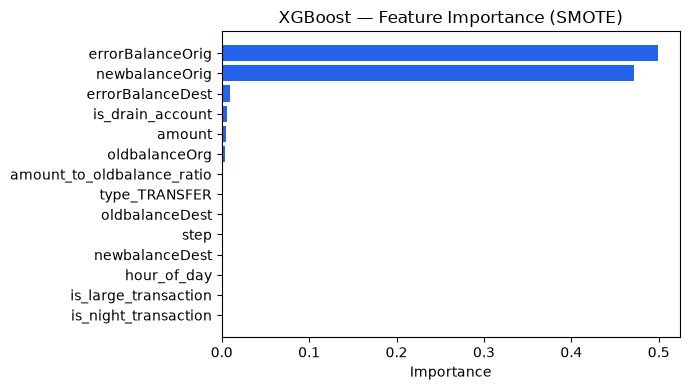

In [4]:
fi = get_feature_importance(model, feature_names, top_n=14)
display(fi)

plt.figure(figsize=(7, 4))
plt.barh(fi["Feature"][::-1], fi["Importance"][::-1], color="#2563eb")
plt.title("XGBoost — Feature Importance (SMOTE)")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

## 4. Quick Evaluation (test set)

In [5]:
y_pred, y_prob = predict(model, X_test)
metrics = evaluate_model(y_test, y_pred, y_prob, "XGB-SMOTE")


📊 XGB-SMOTE — Evaluation Results
  F1-Score:   0.9963
  Precision:  0.9976
  Recall:     0.9951
  ROC-AUC:    0.9993

Confusion Matrix:
  TN=38,353  FP=4
  FN=8  TP=1,635

              precision    recall  f1-score   support

      Normal     0.9998    0.9999    0.9998     38357
       Fraud     0.9976    0.9951    0.9963      1643

    accuracy                         0.9997     40000
   macro avg     0.9987    0.9975    0.9981     40000
weighted avg     0.9997    0.9997    0.9997     40000



## 5. So sánh với Random Forest (Phase 03)
Đọc số liệu RF từ `reports/rf_smote_summary.txt` nếu có.

In [6]:
rf_path = os.path.join("..", "reports", "rf_smote_summary.txt")
print(open(rf_path, encoding="utf-8").read() if os.path.exists(rf_path) else "(chưa có rf_smote_summary.txt)")

summary = pd.DataFrame([
    {"Model": "XGB-SMOTE", "F1": metrics["f1_score"], "Precision": metrics["precision"],
     "Recall": metrics["recall"], "ROC-AUC": metrics["roc_auc"]},
])
summary

  Random Forest Model Summary
  Model: RF-SMOTE

--- Evaluation Metrics (Test Set) ---
  F1-Score:   0.9973
  Precision:  0.9994
  Recall:     0.9951
  ROC-AUC:    0.9994

--- Training Info ---
  Tuned:              True
  Training Time:      1187.68s
  Best CV Score:      0.9993

--- Best Hyperparameters ---
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt
  max_depth: 20
  class_weight: balanced_subsample

--- Confusion Matrix ---
  [[38356     1]
 [    8  1635]]

--- Classification Report ---
              precision    recall  f1-score   support

      Normal     0.9998    1.0000    0.9999     38357
       Fraud     0.9994    0.9951    0.9973      1643

    accuracy                         0.9998     40000
   macro avg     0.9996    0.9976    0.9986     40000
weighted avg     0.9998    0.9998    0.9998     40000



,Model,F1,Precision,Recall,ROC-AUC
0,XGB-SMOTE,0.9963,0.9976,0.9951,0.9993


## 6. Save Model

In [7]:
save_model(model, "xgb_smote")   # -> models/xgb_smote.pkl (+ .json)

💾 Model saved: C:\Users\ADMIN\OneDrive\Documents\TRÍ TUỆ NHÂN TẠO\PROJECT CUỐI KỲ\CS106-Team09-Fraud-Detection\draft\fraud-detection\models\xgb_smote.pkl (0.41 MB)


'C:\\Users\\ADMIN\\OneDrive\\Documents\\TRÍ TUỆ NHÂN TẠO\\PROJECT CUỐI KỲ\\CS106-Team09-Fraud-Detection\\draft\\fraud-detection\\models\\xgb_smote.pkl'

## 7. Kết luận
- XGBoost-SMOTE đạt **F1 ≈ 0.996 / ROC-AUC ≈ 0.999** trên test — vượt mốc (F1 > 0.75, AUC > 0.93) và ngang Random Forest.
- `errorBalanceOrig`, `is_drain_account`, `newbalanceOrig` là các đặc trưng chi phối — khớp trực giác nghiệp vụ (tài khoản bị rút sạch).
- Chi tiết artifact: `reports/xgb_smote_summary.txt`, `reports/xgb_smote_feature_importance.csv`, `reports/xgb_predictions.pkl`.
